# Markov chain version of the simple slot machine example

This notebook shows a markov chain implementation of the "simple slot machine" example. The goal is to have a simple and clear implementation, which is why it is coded without use of  python software packages. In further versions of this work, the examples shown below could be compared to those from existing packages such as [PyDTMC](https://pypi.org/project/PyDTMC/). PyDTMC is a full-featured, lightweight Python library for creating, analyzing, and simulating discrete-time Markov chains, including tools for classification, sensitivity analysis, and visualization.

Representation of the Markov chain for the "simple slot machine":

<p align="center">
<img src="images_notebook/2x3 slot machine 4.png" width="400">
</p>

The code below implements the slot machine shown in the "Another Introduction to GTS". 

The central element of Markov chains are the *state transition matrices* $P$. These describe the system by assining the probability of a state $i$ going to a state $j$. Therefore:
1. The rows are stochastic (i.e. all elements are non-negative and sum to 1). 
2. The probabilities at $t_{n+1}$ are given by $b(t_{n+1}) = P_{i,j}b(t_{i})$

We build the $P$ matrix for the simple slot machine "by hand":
1. First, each arc has the same probability, meanining that each element of $P$ has the same value $v$.
2. Each state has an arc toward itself, therefore $P_{i,i} = v$
3. The remaining arcs are "filled in" by following how each state is connected to the next

The result is shown below:

In [10]:
import numpy as np

# Transition matrix P
P = (1/3) * np.array([
    [1, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 1, 0, 0, 0],

    [0, 0, 0, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1, 0, 0, 1],

    [1, 0, 0, 0, 0, 0, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 1],
    [0, 0, 1, 0, 0, 0, 1, 0, 1]
], dtype=float)

# Size (should be 9)
n = P.shape[0]

## Calculation of probabilities after $k$ steps

In order to calculate the probabilities of states after $k$ timesteps, we generalise the equation to predict the next probabilities from $p(t_{n+1}) = P_{i,j}p(t_{i})$ to 

$$p_k = P_{i,j}^k p $$

In [13]:
# Right-hand side: first equation enforces sum(pi) = 1, others are 0
b = np.zeros(n)
b[0] = 1.0 # we assume that the slot machine starts at the first state ("0,0"), hence the probability of being there is 1.

# Probabilities after k steps:
k = 3          # 3 timesteps
I_i = b.copy() # same as in MATLAB example
p = np.linalg.matrix_power(P, k) @ I_i

print("Probability after k = 3 steps: ")
print("b_{k=3} = ", p)

Probability after k = 3 steps: 
b_{k=3} =  [0.11111111 0.11111111 0.11111111 0.11111111 0.         0.11111111
 0.11111111 0.11111111 0.22222222]


## Calculation of the steady state

An interesting property of any system is to calculate it's steady state. For markov chains, the corresponds to the steady-state condition, i.e. $b_{i+1} = b_i$, which translates to $b_i = Pb_i$, which means that any $b$ are the *eigenvectors* of $P$.

For a Markov chain, the eigenvalues and eigenvectors of the transition matrix describe its long-term and transient behavior:
- The eigenvalue 1 and its corresponding eigenvector give the stationary distribution (when it exists and is unique): a probability vector $b$ such that $b_i = Pb_i$, meaning the distribution does not change after further steps. 
- Eigenvalues with absolute value less than 1 and their eigenvectors describe transient modes: their contributions decay like $\lambda_i^n$ as you apply $P^n$, so they control how fast and in what manner the chain converges to stationarity (the spectral gap $1 - |\lambda_2|$ is directly tied to the mixing rate). 
- For irreducible, aperiodic chains on a finite state space, 1 is the unique eigenvalue of magnitude 1; all other eigenvalues lie strictly inside the unit circle, ensuring convergence to the stationary distribution regardless of the initial state.

Let's look at the eigenvalues for our simple slot machine:

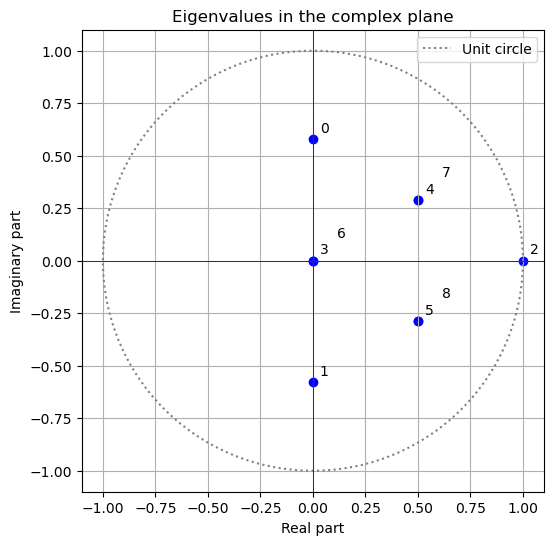

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(P)

# Complex plane coordinates
x = eigvals.real
y = eigvals.imag

plt.figure(figsize=(6, 6))
plt.scatter(x, y, color="blue")

# Keep track of how many times each point appears
seen = defaultdict(int)

for idx, val in enumerate(eigvals):
    # Round coordinates slightly so numerically equal values are grouped
    key = (round(val.real, 10), round(val.imag, 10))
    count = seen[key]
    seen[key] += 1

    # Different offsets for repeated eigenvalues
    dx = 5 + 12 * count
    dy = 5 + 12 * count

    plt.annotate(
        str(idx),
        (val.real, val.imag),
        textcoords="offset points",
        xytext=(dx, dy),
        ha="left"
    )

# Plot the unit circle
theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), linestyle=":", color="gray", label="Unit circle")

# Axes
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)

plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.title("Eigenvalues in the complex plane")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()

plt.show()

The plot above shows that there is only a single eigenvalue that is not transient: all others are within the unit-circle. Let's look at the eigenvector associated with the 2nd eigenvalue: 

In [24]:
i = 2 # 2nd eigenvalue
print(f"Eigenvalue {i+1}: {eigvals[i]:.3f}")
print("Eigenvector:")
for value in eigvecs[:, i]:
    print(f"{value:.3f}")
print("-" * 40)

Eigenvalue 3: 1.000+0.000j
Eigenvector:
-0.333+0.000j
-0.333+0.000j
-0.333+0.000j
-0.333+0.000j
-0.333+0.000j
-0.333+0.000j
-0.333+0.000j
-0.333+0.000j
-0.333+0.000j
----------------------------------------


This vector can be scaled to a constant vector $b = 1/9 \times (1, 1, ... 1)$, which represents a state where on average all states have equal probabilities.

# Conclusion

The markov analysis shows that $on average$, the win rate for the simple slot machine is $P_{win} = b_1 + b_5 + b_9 = 1/9 \times 3 = 1/3$.
